In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Load Iris dataset 
iris = datasets.load_iris()
X = iris.data  # Features
y = iris.target  # Class labels

# Normalize the data 
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean  # Centering


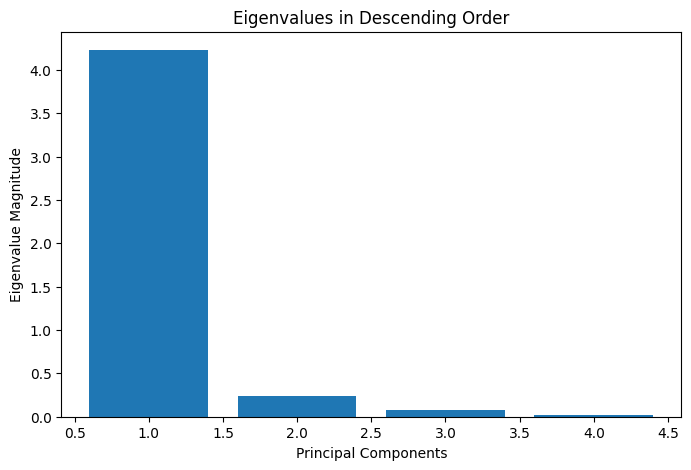

In [2]:
# covariance matrix
cov_matrix = np.cov(X_centered.T)  

# eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort  in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Plot 
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(eigenvalues) + 1), eigenvalues)
plt.xlabel("Principal Components")
plt.ylabel("Eigenvalue Magnitude")
plt.title("Eigenvalues in Descending Order")
plt.show()


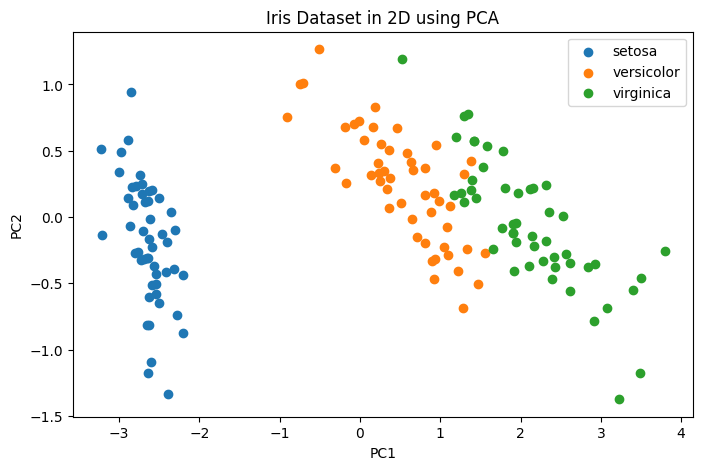

In [3]:
# first 2 principal components
W = eigenvectors[:, :2]  
X_pca = X_centered @ W  # Transform data to 2D

# Visualize PCA-transformed
plt.figure(figsize=(8, 5))
for label in np.unique(y):
    plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1], label=iris.target_names[label])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Iris Dataset in 2D using PCA")
plt.legend()
plt.show()


In [4]:
class_means = []
class_covs = []
for label in np.unique(y):
    X_class = X_pca[y == label]
    class_means.append(np.mean(X_class, axis=0))
    class_covs.append(np.cov(X_class.T))  # Compute class-wise covariance


In [5]:
from scipy.stats import multivariate_normal

def bayesian_predict(X):
    class_probs = []
    for i, label in enumerate(np.unique(y)):
        likelihood = multivariate_normal.pdf(X, mean=class_means[i], cov=class_covs[i])
        class_probs.append(likelihood)
    return np.argmax(class_probs, axis=0)


X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# Predict
y_pred = np.array([bayesian_predict(x) for x in X_test])

#  accuracy
accuracy = np.mean(y_pred == y_test)
error_rate = 1 - accuracy

print(f"Bayesian Classifier Accuracy: {accuracy * 100:.2f}%")
print(f"Error Rate: {error_rate * 100:.2f}%")


Bayesian Classifier Accuracy: 97.78%
Error Rate: 2.22%


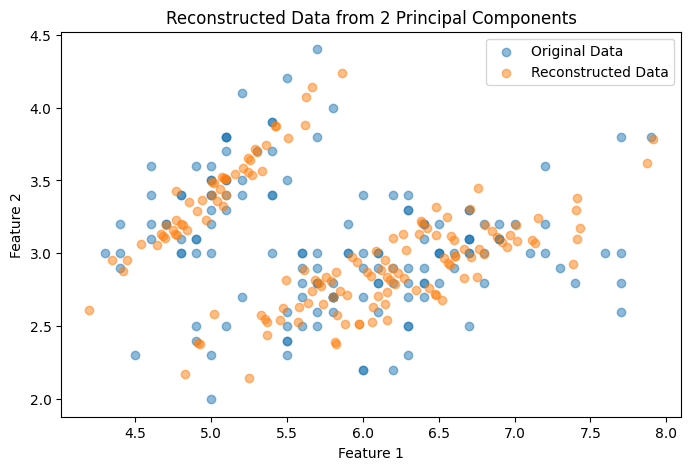

In [6]:
# Reconstruct from first 2 PCs
X_reconstructed = (X_pca @ W.T) + X_mean

# Plot original vs reconstructed
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], label="Original Data", alpha=0.5)
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], label="Reconstructed Data", alpha=0.5)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Reconstructed Data from 2 Principal Components")
plt.legend()
plt.show()
